# SDS5034X — Waveform Snapshot via WAV Commands

Verbindung mit dem Gerät herstellen, dann einen Snapshot des aktuellen
Bildschirminhalts als Rohdaten lesen und als CSV speichern.

In [44]:
import pyvisa
import struct
import math
import csv
from pathlib import Path

rm = pyvisa.ResourceManager()
inst: pyvisa.resources.MessageBasedResource = rm.open_resource('USB0::0xF4EC::0x1016::SDS3HA0Q800428::INSTR')  # type: ignore[assignment]
inst.encoding = 'latin-1'
inst.timeout = 10_000  # 10 s, Waveform-Transfer kann dauern

print(inst.query('*IDN?'))
print(inst.query('*OPC?'))

Siglent Technologies,SDS3034X HD,SDS3HA0Q800428,4.8.9.1.0.3.9

1



## Schritt 1 — Oszi stoppen

Bevor die WAV-Daten gelesen werden, muss die Acquisition eingefroren werden,
damit die Daten konsistent sind.

In [45]:
inst.write(':TRIGger:STOP')
print('Trigger-Status:', inst.query(':TRIGger:STATus?').strip())

Trigger-Status: Stop


## Schritt 2 — Preamble lesen und parsen

`:WAV:PRE?` liefert einen 346-Byte-WAVEDESC-Block mit allen Metadaten:
V/div, Offset, Abtastintervall, Triggerverzögerung, ADC-Auflösung usw.

Aus diesen Werten wird später die Konformel berechnet:

```
Spannung = code / code_per_div * vdiv − voffset
Zeit     = −delay − (tdiv × 10 / 2) + index × interval
```

In [46]:
CHANNEL = 'C1'   # <-- hier ggf. anpassen: C1, C2, C3, C4

# Quelle setzen, Startpunkt auf 0
inst.write(f':WAVeform:SOURce {CHANNEL}')
inst.write(':WAVeform:STARt 0')

# Preamble abfragen: rohes binäres Paket
inst.write(':WAVeform:PREamble?')
preamble_raw = inst.read_raw()

# Den WAVEDESC-Block extrahieren (nach "#9xxxxxxxxx" = 11 Zeichen nach '#')
hash_pos = preamble_raw.find(b'#')
desc = preamble_raw[hash_pos + 11:]

# Felder aus dem WAVEDESC parsen (Byte-Offsets laut Programming Guide)
comm_order   = struct.unpack_from('<h', desc, 0x22)[0]  # 0=LSB, 1=MSB
endian       = '>' if comm_order else '<'

vdiv         = struct.unpack_from(f'{endian}f', desc, 0x9C)[0]   # V/div (ohne Probe)
voffset      = struct.unpack_from(f'{endian}f', desc, 0xA0)[0]   # Offset V (ohne Probe)
code_per_div = struct.unpack_from(f'{endian}f', desc, 0xA4)[0]   # ADC-Codes pro div
adc_bit      = struct.unpack_from(f'{endian}h', desc, 0xAC)[0]   # ADC-Auflösung (8/10/12)
interval     = struct.unpack_from(f'{endian}f', desc, 0xB0)[0]   # Abtastintervall (s)
delay        = struct.unpack_from(f'{endian}d', desc, 0xB4)[0]   # Trigger-Delay (s)
probe        = struct.unpack_from(f'{endian}f', desc, 0x148)[0]  # Probe-Faktor
wave_count   = struct.unpack_from(f'{endian}l', desc, 0x74)[0]   # Anzahl Datenpunkte

# Probe-Faktor auf V/div und Offset anwenden
vdiv    *= probe
voffset *= probe

print(f'Kanal:          {CHANNEL}')
print(f'ADC-Bits:       {adc_bit}')
print(f'V/div:          {vdiv:.6f} V')
print(f'Offset:         {voffset:.6f} V')
print(f'code_per_div:   {code_per_div:.2f}')
print(f'Abtastintervall:{interval:.3e} s  →  Samplerate: {1/interval:.3e} Sa/s')
print(f'Trigger-Delay:  {delay:.6e} s')
print(f'Probe:          {probe}x')
print(f'Datenpunkte:    {wave_count}')

Kanal:          C1
ADC-Bits:       16
V/div:          0.074000 V
Offset:         0.000000 V
code_per_div:   6800.00
Abtastintervall:2.000e-07 s  →  Samplerate: 5.000e+06 Sa/s
Trigger-Delay:  0.000000e+00 s
Probe:          1.0x
Datenpunkte:    10000


## Schritt 3 — Rohdaten lesen

Das Gerät überträgt maximal `:WAV:MAXP?` Punkte pro Aufruf.
Bei mehr Punkten wird in mehreren Stücken gelesen (`STARt` verschieben).

In [47]:
# Datenbreite setzen: BYTE für 8-bit ADC (SDS5034X), WORD für 10/12-bit Modelle
if adc_bit > 8:
    inst.write(':WAVeform:WIDTh WORD')
    bytes_per_sample = 2
else:
    inst.write(':WAVeform:WIDTh BYTE')
    bytes_per_sample = 1

# Maximale Punkte pro Lesevorgang abfragen
max_pts = int(inst.query(':WAVeform:MAXPoint?').strip())
total_pts = wave_count
read_chunks = math.ceil(total_pts / max_pts)

print(f'bytes_per_sample: {bytes_per_sample}')
print(f'max_pts pro Chunk: {max_pts}')
print(f'total_pts:         {total_pts}')
print(f'Chunks benötigt:   {read_chunks}')

raw_codes: list[int] = []

for chunk_idx in range(read_chunks):
    start_pt = chunk_idx * max_pts
    pts_this_chunk = min(max_pts, total_pts - start_pt)

    inst.write(f':WAVeform:STARt {start_pt}')
    inst.write(f':WAVeform:POINt {pts_this_chunk}')
    inst.write(':WAVeform:DATA?')

    chunk_raw = inst.read_raw().rstrip(b'\n')

    # IEEE 488.2 Binary Block Header überspringen: "#N<N Ziffern><Daten>"
    hash_pos = chunk_raw.find(b'#')
    n_digits = int(chunk_raw[hash_pos + 1 : hash_pos + 2])
    data_start = hash_pos + 2 + n_digits
    payload = chunk_raw[data_start:]

    if bytes_per_sample == 1:
        # 8-bit: jedes Byte ist ein vorzeichenloser Code
        for b in payload:
            code = b if b <= 127 else b - 256  # unsigned → signed
            raw_codes.append(code)
    else:
        # 16-bit WORD: zwei Bytes pro Sample, Big-Endian (MSB first laut Guide)
        for i in range(0, len(payload) - 1, 2):
            code = struct.unpack_from(f'{endian}h', payload, i)[0]
            raw_codes.append(code)

    print(f'  Chunk {chunk_idx + 1}/{read_chunks}: {len(payload)} Bytes gelesen')

print(f'\nGesamt codes gelesen: {len(raw_codes)}')

bytes_per_sample: 2
max_pts pro Chunk: 400000000
total_pts:         10000
Chunks benötigt:   1
  Chunk 1/1: 20000 Bytes gelesen

Gesamt codes gelesen: 10000


## Schritt 4 — Codes in physikalische Einheiten umrechnen

**Spannung:**
$$U = \frac{code}{code\_per\_div} \cdot v_{div} - v_{offset}$$

**Zeit:**
$$t = -delay - \frac{t_{div} \cdot 10}{2} + index \cdot interval$$

Der Faktor 10 steht für die 10 Zeitraster-Divisionen des SDS5034X.

In [48]:
GRID_DIVS = 10  # SDS5034X hat 10 horizontale Divisionen

voltages = [code / code_per_div * vdiv - voffset for code in raw_codes]
times    = [-delay - (interval * total_pts / 2) + i * interval for i in range(len(raw_codes))]

print(f'Erste 5 Zeitpunkte (s): {[f"{t:.3e}" for t in times[:5]]}')
print(f'Erste 5 Spannungen (V): {[f"{v:.4f}" for v in voltages[:5]]}')

Erste 5 Zeitpunkte (s): ['-1.000e-03', '-9.998e-04', '-9.996e-04', '-9.994e-04', '-9.992e-04']
Erste 5 Spannungen (V): ['0.0205', '0.0449', '0.0693', '0.0923', '0.1144']


## Schritt 5 — Als CSV speichern

Die Daten werden als `snapshot_<Kanal>.csv` im Notebook-Ordner abgelegt.

In [49]:
output_path = Path(__file__).parent / f'snapshot_{CHANNEL}.csv' if '__file__' in dir() else Path(f'snapshot_{CHANNEL}.csv')

with open(output_path, 'w', newline='') as f:
    writer = csv.writer(f)
    # Metadaten als Kommentar-Header
    writer.writerow([f'# Kanal: {CHANNEL}'])
    writer.writerow([f'# ADC-Bits: {adc_bit}'])
    writer.writerow([f'# V/div: {vdiv} V'])
    writer.writerow([f'# Offset: {voffset} V'])
    writer.writerow([f'# Abtastintervall: {interval} s'])
    writer.writerow([f'# Trigger-Delay: {delay} s'])
    writer.writerow([f'# Probe: {probe}x'])
    writer.writerow([f'# Datenpunkte: {len(voltages)}'])
    # Daten
    writer.writerow(['time_s', 'voltage_V'])
    writer.writerows(zip(times, voltages))

print(f'Gespeichert: {output_path.resolve()}')
print(f'Zeilen: {len(voltages)}')

Gespeichert: C:\Users\Justin Hennig\Documents\Praktikum2026\Praktikum2026\Testing\Notebooks\snapshot_C1.csv
Zeilen: 10000


## Schritt 6 — Oszi wieder starten

Nach dem Lesen die Acquisition wieder freigeben.

In [50]:
inst.write(':TRIGger:RUN')
print('Trigger-Status:', inst.query(':TRIGger:STATus?').strip())

Trigger-Status: Arm


## Bonus — Daten aus CSV wieder einlesen und plotten

Zum Überprüfen: gespeicherte CSV laden und schnell visualisieren.

     time_s  voltage_V
0 -0.001000   0.020546
1 -0.001000   0.044922
2 -0.001000   0.069299
3 -0.000999   0.092282
4 -0.000999   0.114395


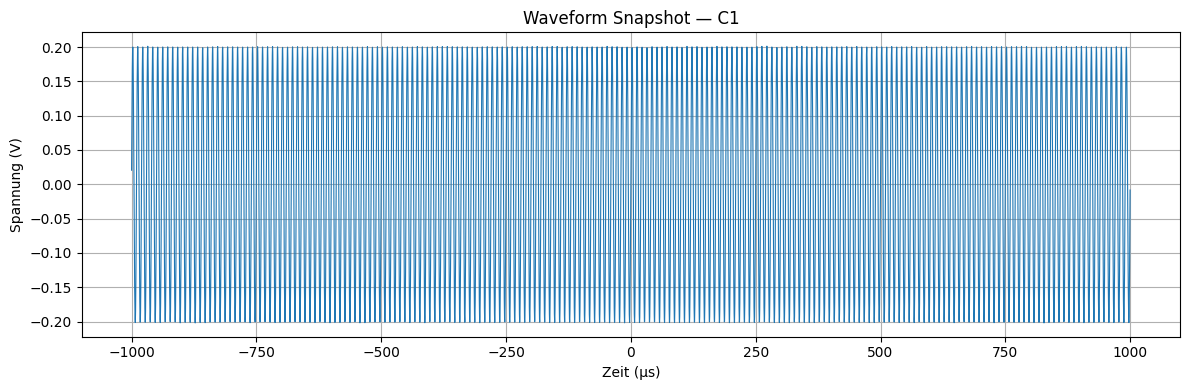

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Kommentar-Zeilen (#) beim Einlesen überspringen
df = pd.read_csv(output_path, comment='#')
print(df.head())

plt.figure(figsize=(12, 4))
plt.plot(df['time_s'] * 1e6, df['voltage_V'], linewidth=0.8)
plt.xlabel('Zeit (µs)')
plt.ylabel('Spannung (V)')
plt.title(f'Waveform Snapshot — {CHANNEL}')
plt.grid(True)
plt.tight_layout()
plt.show()